XGBoost Model with 23 features

Importing all the necessary Libraries 

In [1]:
# Standard library
import os
import random
from datetime import datetime

# Data manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Machine learning
from sklearn.metrics import mean_squared_error, mean_absolute_error
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit

# Financial data
import yfinance as yf

Removing randomness from the model to enforce consistent results

In [2]:
#Ensures hash-based operations (like in dicts, sets, or some internal functions) are reproducible across runs
os.environ['PYTHONHASHSEED'] = '0'  # For hash-based operations

#Makes Python’s built-in random module deterministic.
random.seed(42)

#Makes NumPy random operations deterministic (used by scikit-learn, pandas sampling, etc.).
np.random.seed(42)

Code to fetch and download data (Apple Stock Price) from Yahoo everyday roughly for the past 10 years 

In [3]:
#Downloading historical stock data from Apple for the pat 10 years
#The resulting data is a datframe with columns [Open, High, Low, Close, Volume] with the index being the date of each trading day.

ticker = 'AAPL'  
data = yf.download(ticker, start="2015-01-01", end="2025-12-26")

#moving date from the index into a regular column - this allows you to extract the dates
data.reset_index(inplace=True)

if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.get_level_values(0)

data['Date'] = pd.to_datetime(data['Date'])
data = data.sort_values('Date').reset_index(drop=True)

#Creating Lag features
lags = [1, 2, 5, 10]

for lag in lags:
    data[f'Close_t-{lag}'] = data['Close'].shift(lag)

#Creating a Return feature - computing the percentage change from yestredays day
data['Return_t-1'] = data['Close'].pct_change(1)
data['Return_t-2'] = data['Close'].pct_change(2)
data['Return_t-5'] = data['Close'].pct_change(5)

# Moving Averages features
data['MA_10'] = data['Close'].rolling(window=10).mean() #10 day moving average
data['MA_50'] = data['Close'].rolling(window=50).mean() #50 day moving average

# Relative distance features 
data['Close_to_MA10'] = (data['Close'] - data['MA_10']) / data['MA_10']
data['Close_to_MA50'] = (data['Close'] - data['MA_50']) / data['MA_50']
data['MA10_to_MA50'] = (data['MA_10'] - data['MA_50']) / data['MA_50']

#Volatility features
data['Volatility_5'] = data['Return_t-1'].rolling(window=5).std()
data['Volatility_20'] = data['Return_t-1'].rolling(window=20).std()

#Volume features
data['Volume_t-1'] = data['Volume'].shift(1)
data['Volume_MA10'] = data['Volume'].rolling(window=10).mean()
data['Volume_MA20'] = data['Volume'].rolling(window=20).mean()

data['Volume_Change'] = (data['Volume'] - data['Volume_MA10']) / data['Volume_MA10']
data['Volume_Spike'] = data['Volume'] / data['Volume_MA20']


#RSI 14 (Relative Strength Index) - a momentum indicator showing whether a stock is overbought or oversold
rsi_window = 14

delta = data['Close'].diff()

gain = delta.clip(lower=0)
loss = -delta.clip(upper=0)

# Use Wilder's Smoothing (alpha = 1/window)
avg_gain = gain.ewm(alpha=1/rsi_window, min_periods=rsi_window, adjust=False).mean()
avg_loss = loss.ewm(alpha=1/rsi_window, min_periods=rsi_window, adjust=False).mean()

rs = avg_gain / (avg_loss + 1e-10)
data['RSI'] = 100 - (100 / (1 + rs))

features = [
    'Close_t-1', 'Close_t-2', 'Close_t-5', 'Close_t-10',
    'Return_t-1', 'Return_t-2', 'Return_t-5',
    'MA_10', 'MA_50',
    'Close_to_MA10', 'Close_to_MA50', 'MA10_to_MA50',
    'Volatility_5', 'Volatility_20',
    'RSI'] 

#Target: next‑day close price
data["target_next_close"] = data["Close"].shift(-1)

#Drop NaNs created by rolling windows and the shift
data = data.dropna().reset_index(drop=True)


X = data[features]
y = data["target_next_close"]

C:\Users\Sxk1332\AppData\Local\Temp\ipykernel_24948\4033678131.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start="2015-01-01", end="2025-12-26")
[*********************100%***********************]  1 of 1 completed


Splitting the data into a training set (first 85%) and testing set (remaining 15%)

In [4]:
total_size = len(data)

train_size = int(len(data) * 0.70)
val_size   = int(len(data) * 0.15)

train_data = data[:train_size]
val_data = data[train_size:train_size + val_size]
test_data = data[train_size + val_size:]

print("Total samples:", total_size)

print("\nDataset sizes:")
print(f"Training set   : {len(train_data)} samples ({len(train_data)/total_size:.2%})")
print(f"Validation set : {len(val_data)} samples ({len(val_data)/total_size:.2%})")
print(f"Test set       : {len(test_data)} samples ({len(test_data)/total_size:.2%})")

print("Train:", train_data.shape)
print("Val  :", val_data.shape)
print("Test :", test_data.shape)

print("\nCheck sum:", len(train_data) + len(val_data) + len(test_data))

Total samples: 2712

Dataset sizes:
Training set   : 1898 samples (69.99%)
Validation set : 406 samples (14.97%)
Test set       : 408 samples (15.04%)
Train: (1898, 27)
Val  : (406, 27)
Test : (408, 27)

Check sum: 2712


In [5]:
X_train = train_data[features].values
X_val   = val_data[features].values
X_test  = test_data[features].values


y_train = train_data['target_next_close'].values
y_val   = val_data['target_next_close'].values
y_test  = test_data['target_next_close'].values

Training the XGBoost Model

In [6]:
import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score

model = xgb.XGBRegressor(
    objective="reg:squarederror",
    n_estimators=300,   #Number of trees in the forest, usually more trees = better performance but slower
    learning_rate=0.03,     
    max_depth=10,    #Maximum depth of each tree. Limits overfitting, smaller = simpler tree. Larger = more complex tree
    subsample=0.8,          
    min_child_weight=5,
    colsample_bytree=0.8,   
    gamma=0.1,
    reg_lambda=0.5,         
    reg_alpha=0.1,          
    tree_method="hist",     
    n_jobs=-1,
    random_state=42,
    early_stopping_rounds=60,
    eval_metric=['mae', 'rmse'] 
)

model.fit(X_train,
    y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=True
)


[0]	validation_0-mae:40.42133	validation_0-rmse:46.45249	validation_1-mae:95.36981	validation_1-rmse:97.12316
[1]	validation_0-mae:39.21564	validation_0-rmse:45.07214	validation_1-mae:92.80542	validation_1-rmse:94.55276
[2]	validation_0-mae:38.04506	validation_0-rmse:43.73362	validation_1-mae:90.32154	validation_1-rmse:92.06416
[3]	validation_0-mae:36.90961	validation_0-rmse:42.43443	validation_1-mae:87.89661	validation_1-rmse:89.63490
[4]	validation_0-mae:35.80737	validation_0-rmse:41.17316	validation_1-mae:85.56161	validation_1-rmse:87.29777
[5]	validation_0-mae:34.73885	validation_0-rmse:39.95016	validation_1-mae:83.27776	validation_1-rmse:85.01046
[6]	validation_0-mae:33.70331	validation_0-rmse:38.76459	validation_1-mae:81.05096	validation_1-rmse:82.78036
[7]	validation_0-mae:32.69842	validation_0-rmse:37.61431	validation_1-mae:78.89733	validation_1-rmse:80.62457
[8]	validation_0-mae:31.72536	validation_0-rmse:36.50150	validation_1-mae:76.82868	validation_1-rmse:78.55602
[9]	valida

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,60
,enable_categorical,False
,eval_metric,"['mae', 'rmse']"


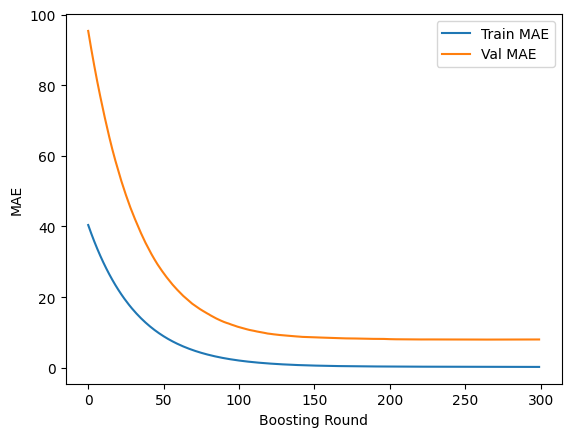

In [7]:
results = model.evals_result()

# Training metrics
train_mae = results['validation_0']['mae']
val_mae = results['validation_1']['mae']
# Plot RMSE over rounds
import matplotlib.pyplot as plt

plt.plot(train_mae, label='Train MAE')
plt.plot(val_mae, label='Val MAE')
plt.xlabel('Boosting Round')
plt.ylabel('MAE')
plt.legend()
plt.show()

Predictions:

In [8]:
y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print(f"Test RMSE: {rmse:.4f}")
print(f"Test MAE: {mae:.4f}")


Test RMSE: 61.9447
Test MAE: 57.6850


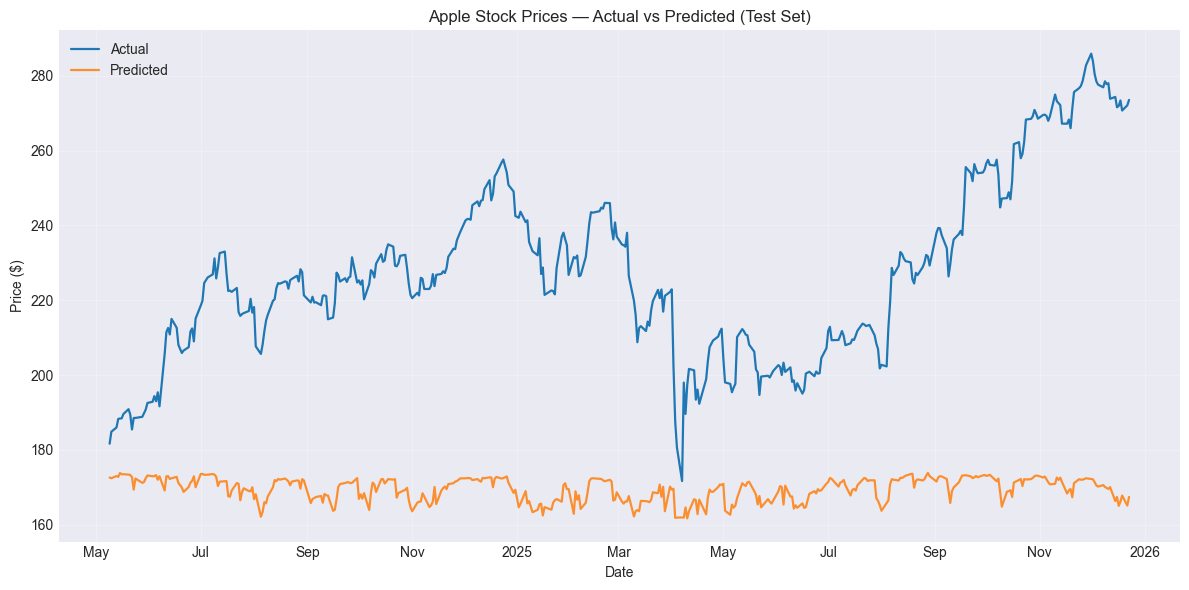

In [9]:
#Make sure dates_test is the same length as y_test/predictions
dates_test = data['Date'][-len(y_pred):].values

plt.style.use('seaborn-v0_8-darkgrid')
plt.figure(figsize=(12, 6))

plt.plot(dates_test, y_test, label="Actual", linewidth=1.6)
plt.plot(dates_test, y_pred, label="Predicted", linewidth=1.6, alpha=0.85)

plt.title("Apple Stock Prices — Actual vs Predicted (Test Set)")
plt.ylabel("Price ($)")
plt.xlabel("Date")
plt.legend()

# Format x-axis dates nicely
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))

plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()